# Curriculum Data Analysis

Visualizes the 4 curriculum levels for the HM3D ObjectNav experiments.

| Level | Houses | Goals | Purpose |
|-------|--------|-------|---------|
| 1 | 1 (fK2vEV32Lag) | chair | Prove WM learns |
| 2 | 1 (fK2vEV32Lag) | all 6 | Impact of missing goal conditioning |
| 3 | 10 scenes | chair | WM generalization across houses |
| 4 | 10 scenes | all 6 | Full complexity |

**Input:** `data/curriculum/level{1-4}_*.json` configs + scene `.json.gz` episode data.

**See also:** `docs/curriculum-preprocessing-plan.md`, `output/scene_analysis/train_scenes_by_difficulty.json`

In [1]:
import gzip
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

CURRICULUM_DIR = Path("../../../data/curriculum")
DATASET_DIR = Path("../../../data/datasets/objectnav/hm3d/objectnav_hm3d_v2/train/content")
SCENE_ANALYSIS = Path("../../../output/scene_analysis/train_scenes_by_difficulty.json")

LEVEL_NAMES = [
    "level1_1house_1goal",
    "level2_1house_6goals",
    "level3_10houses_1goal",
    "level4_10houses_6goals",
]
LEVEL_LABELS = [
    "L1: 1 house, chair",
    "L2: 1 house, 6 goals",
    "L3: 10 houses, chair",
    "L4: 10 houses, 6 goals",
]
LEVEL_COLORS = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# Load all curriculum configs
configs = {}
for name in LEVEL_NAMES:
    with open(CURRICULUM_DIR / f"{name}.json") as f:
        configs[name] = json.load(f)

for name, cfg in configs.items():
    s = cfg["stats"]
    print(f"{name}: {s['total_episodes']} episodes "
          f"(train={s['train_episodes']}, eval={s['eval_episodes']}) "
          f"| {s['scenes_count']} scenes, {s['categories_count']} categories")

level1_1house_1goal: 8333 episodes (train=7499, eval=834) | 1 scenes, 1 categories
level2_1house_6goals: 49998 episodes (train=44998, eval=5000) | 1 scenes, 6 categories
level3_10houses_1goal: 83330 episodes (train=74997, eval=8333) | 10 scenes, 1 categories
level4_10houses_6goals: 499980 episodes (train=449982, eval=49998) | 10 scenes, 6 categories


## 1. Episode Counts by Level

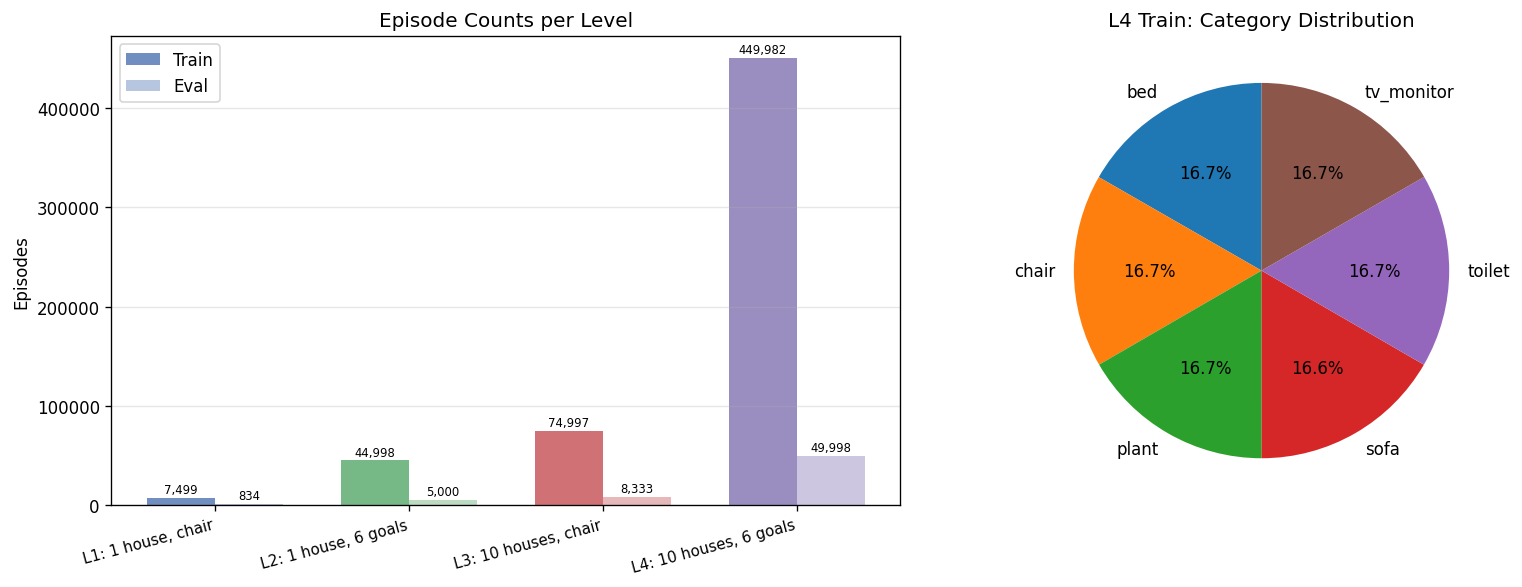

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: total episodes per level
totals = [configs[n]["stats"]["total_episodes"] for n in LEVEL_NAMES]
trains = [configs[n]["stats"]["train_episodes"] for n in LEVEL_NAMES]
evals = [configs[n]["stats"]["eval_episodes"] for n in LEVEL_NAMES]

x = np.arange(len(LEVEL_NAMES))
w = 0.35
axes[0].bar(x - w/2, trains, w, label="Train", color=LEVEL_COLORS, alpha=0.8)
axes[0].bar(x + w/2, evals, w, label="Eval", color=LEVEL_COLORS, alpha=0.4)
axes[0].set_xticks(x)
axes[0].set_xticklabels(LEVEL_LABELS, rotation=15, ha="right", fontsize=9)
axes[0].set_ylabel("Episodes")
axes[0].set_title("Episode Counts per Level")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")
for i, (tr, ev) in enumerate(zip(trains, evals)):
    axes[0].text(i - w/2, tr + totals[-1]*0.01, f"{tr:,}", ha="center", fontsize=7)
    axes[0].text(i + w/2, ev + totals[-1]*0.01, f"{ev:,}", ha="center", fontsize=7)

# Pie chart: L4 breakdown by category
l4_keys = configs["level4_10houses_6goals"]["train_episode_keys"]
from collections import Counter
cat_counts = Counter(k[1] for k in l4_keys)
labels = sorted(cat_counts.keys())
sizes = [cat_counts[l] for l in labels]
axes[1].pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
axes[1].set_title("L4 Train: Category Distribution")

plt.tight_layout()
plt.show()

## 2. Geodesic Distance Distributions

Load the actual episode metadata to compare difficulty across levels.

In [3]:
def load_episode_geodesics(config):
    """Load geodesic distances for all episodes in a curriculum config."""
    # Build key set for train episodes
    train_keys = {(k[0], k[1], k[2]) for k in config["train_episode_keys"]}
    eval_keys = {(k[0], k[1], k[2]) for k in config["eval_episode_keys"]}
    
    train_dists = []
    eval_dists = []
    
    for scene in config["scenes"]:
        path = DATASET_DIR / f"{scene}.json.gz"
        with gzip.open(path, "rt") as f:
            data = json.load(f)
        for ep in data["episodes"]:
            key = (ep["episode_id"], ep["object_category"], scene)
            geo = ep["info"]["geodesic_distance"]
            if key in train_keys:
                train_dists.append(geo)
            elif key in eval_keys:
                eval_dists.append(geo)
    
    return np.array(train_dists), np.array(eval_dists)

# Load geodesics for all 4 levels
geodesics = {}
for name in LEVEL_NAMES:
    train_d, eval_d = load_episode_geodesics(configs[name])
    geodesics[name] = {"train": train_d, "eval": eval_d}
    print(f"{name}: train mean={train_d.mean():.2f}m, eval mean={eval_d.mean():.2f}m")

level1_1house_1goal: train mean=2.95m, eval mean=2.92m


level2_1house_6goals: train mean=3.67m, eval mean=3.67m


level3_10houses_1goal: train mean=4.90m, eval mean=4.92m


level4_10houses_6goals: train mean=5.95m, eval mean=5.91m


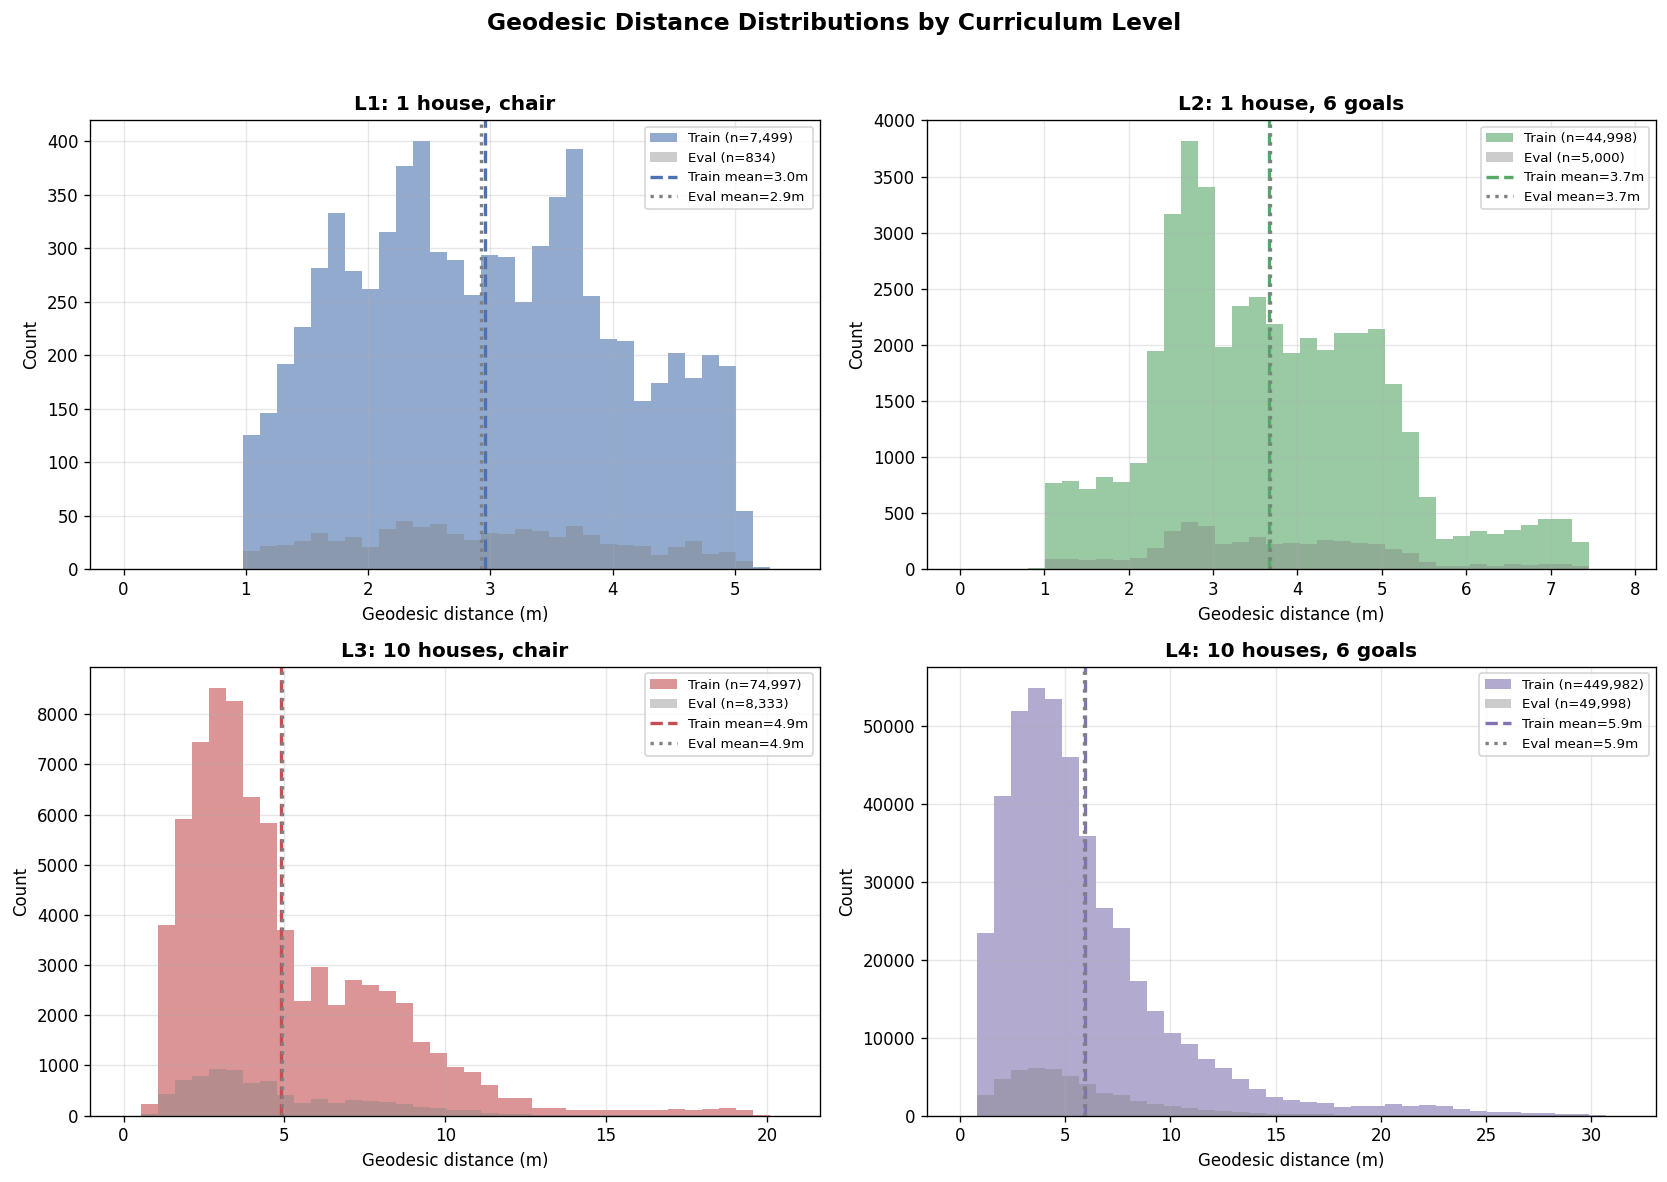

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, name, label, color in zip(axes.flat, LEVEL_NAMES, LEVEL_LABELS, LEVEL_COLORS):
    train_d = geodesics[name]["train"]
    eval_d = geodesics[name]["eval"]
    
    bins = np.linspace(0, max(train_d.max(), eval_d.max()) * 1.05, 40)
    ax.hist(train_d, bins=bins, alpha=0.6, label=f"Train (n={len(train_d):,})", color=color)
    ax.hist(eval_d, bins=bins, alpha=0.4, label=f"Eval (n={len(eval_d):,})", color="gray")
    ax.axvline(train_d.mean(), color=color, linestyle="--", linewidth=2,
               label=f"Train mean={train_d.mean():.1f}m")
    ax.axvline(eval_d.mean(), color="gray", linestyle=":", linewidth=2,
               label=f"Eval mean={eval_d.mean():.1f}m")
    ax.set_xlabel("Geodesic distance (m)")
    ax.set_ylabel("Count")
    ax.set_title(label, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Geodesic Distance Distributions by Curriculum Level", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 3. Per-Scene Breakdown (Levels 3-4)

Shows how difficulty varies across the 10 selected scenes.

/scratch/slurm_tmpdir/job_3907223/ipykernel_505674/408238909.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(bp_data, labels=[s[:8] for s in sorted_scenes],


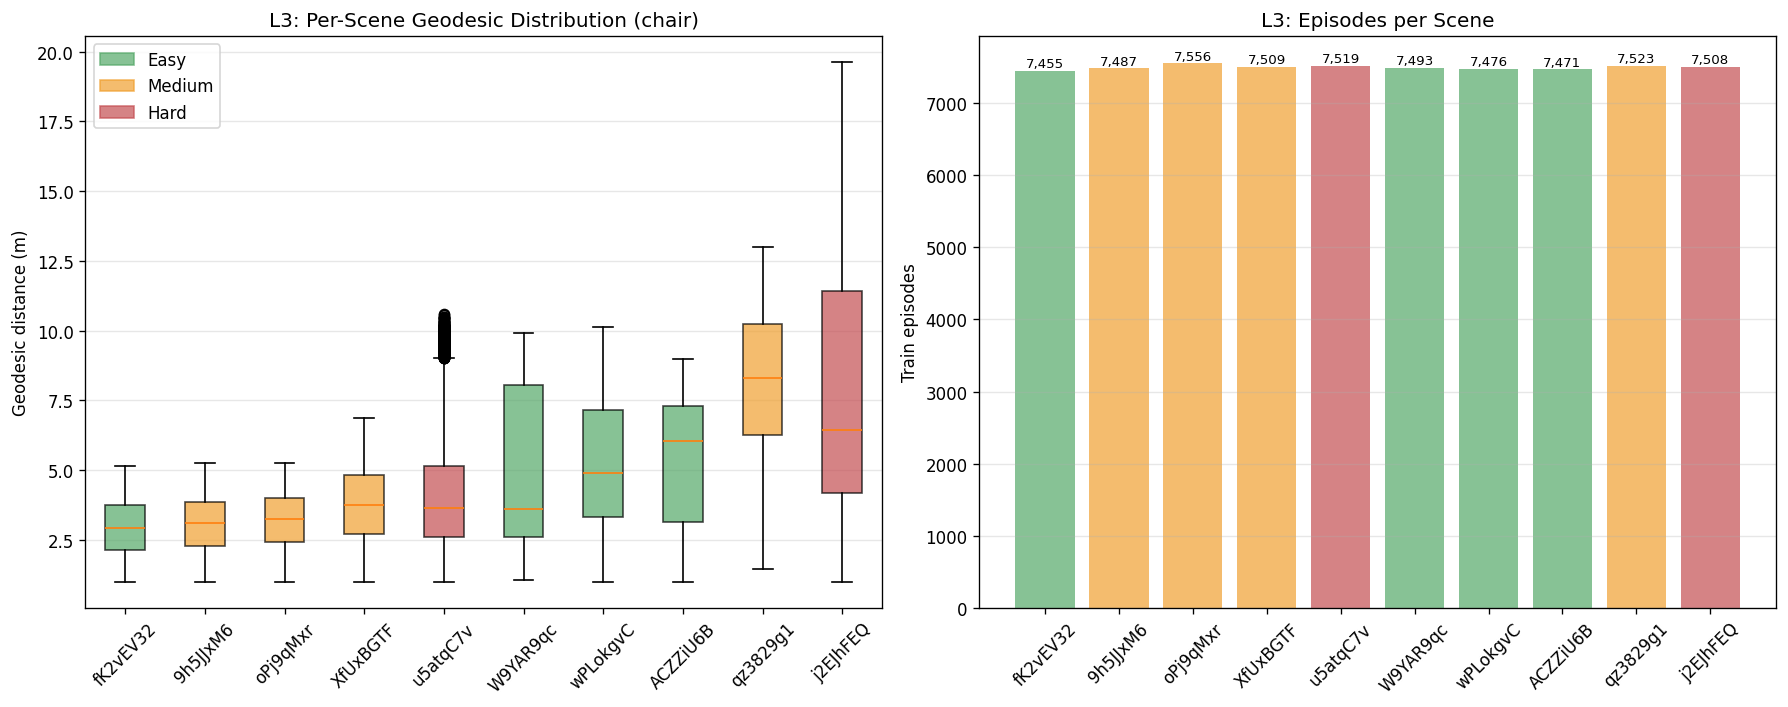

In [5]:
# Load scene analysis for tier labels
with open(SCENE_ANALYSIS) as f:
    scene_analysis = json.load(f)
scene_by_name = {s["name"]: s for s in scene_analysis["scenes"]}

TIER_MAP = {
    "fK2vEV32Lag": "Easy", "W9YAR9qcuvN": "Easy",
    "wPLokgvCnuk": "Easy", "ACZZiU6BXLz": "Easy",
    "XfUxBGTFQQb": "Medium", "9h5JJxM6E5S": "Medium",
    "qz3829g1Lzf": "Medium", "oPj9qMxrDEa": "Medium",
    "u5atqC7vRCY": "Hard", "j2EJhFEQGCL": "Hard",
}
TIER_COLORS = {"Easy": "#55A868", "Medium": "#F0A030", "Hard": "#C44E52"}

# Per-scene geodesic stats for L3 (chair only)
l3_cfg = configs["level3_10houses_1goal"]
l3_train_keys = {(k[0], k[1], k[2]) for k in l3_cfg["train_episode_keys"]}

scene_stats = {}
for scene in l3_cfg["scenes"]:
    path = DATASET_DIR / f"{scene}.json.gz"
    with gzip.open(path, "rt") as f:
        data = json.load(f)
    dists = [ep["info"]["geodesic_distance"] for ep in data["episodes"]
             if (ep["episode_id"], ep["object_category"], scene) in l3_train_keys]
    scene_stats[scene] = np.array(dists)

# Sort by mean geodesic
sorted_scenes = sorted(scene_stats.keys(), key=lambda s: scene_stats[s].mean())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot per scene
bp_data = [scene_stats[s] for s in sorted_scenes]
bp = axes[0].boxplot(bp_data, labels=[s[:8] for s in sorted_scenes],
                     patch_artist=True, vert=True)
for i, scene in enumerate(sorted_scenes):
    bp["boxes"][i].set_facecolor(TIER_COLORS[TIER_MAP[scene]])
    bp["boxes"][i].set_alpha(0.7)
axes[0].set_ylabel("Geodesic distance (m)")
axes[0].set_title("L3: Per-Scene Geodesic Distribution (chair)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3, axis="y")
# Legend for tiers
tier_patches = [mpatches.Patch(color=c, label=t, alpha=0.7) for t, c in TIER_COLORS.items()]
axes[0].legend(handles=tier_patches, loc="upper left")

# Episode count per scene
counts = [len(scene_stats[s]) for s in sorted_scenes]
colors = [TIER_COLORS[TIER_MAP[s]] for s in sorted_scenes]
axes[1].bar(range(len(sorted_scenes)), counts, color=colors, alpha=0.7)
axes[1].set_xticks(range(len(sorted_scenes)))
axes[1].set_xticklabels([s[:8] for s in sorted_scenes], rotation=45)
axes[1].set_ylabel("Train episodes")
axes[1].set_title("L3: Episodes per Scene")
axes[1].grid(True, alpha=0.3, axis="y")
for i, c in enumerate(counts):
    axes[1].text(i, c + 50, f"{c:,}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

## 4. Category Distribution per Level

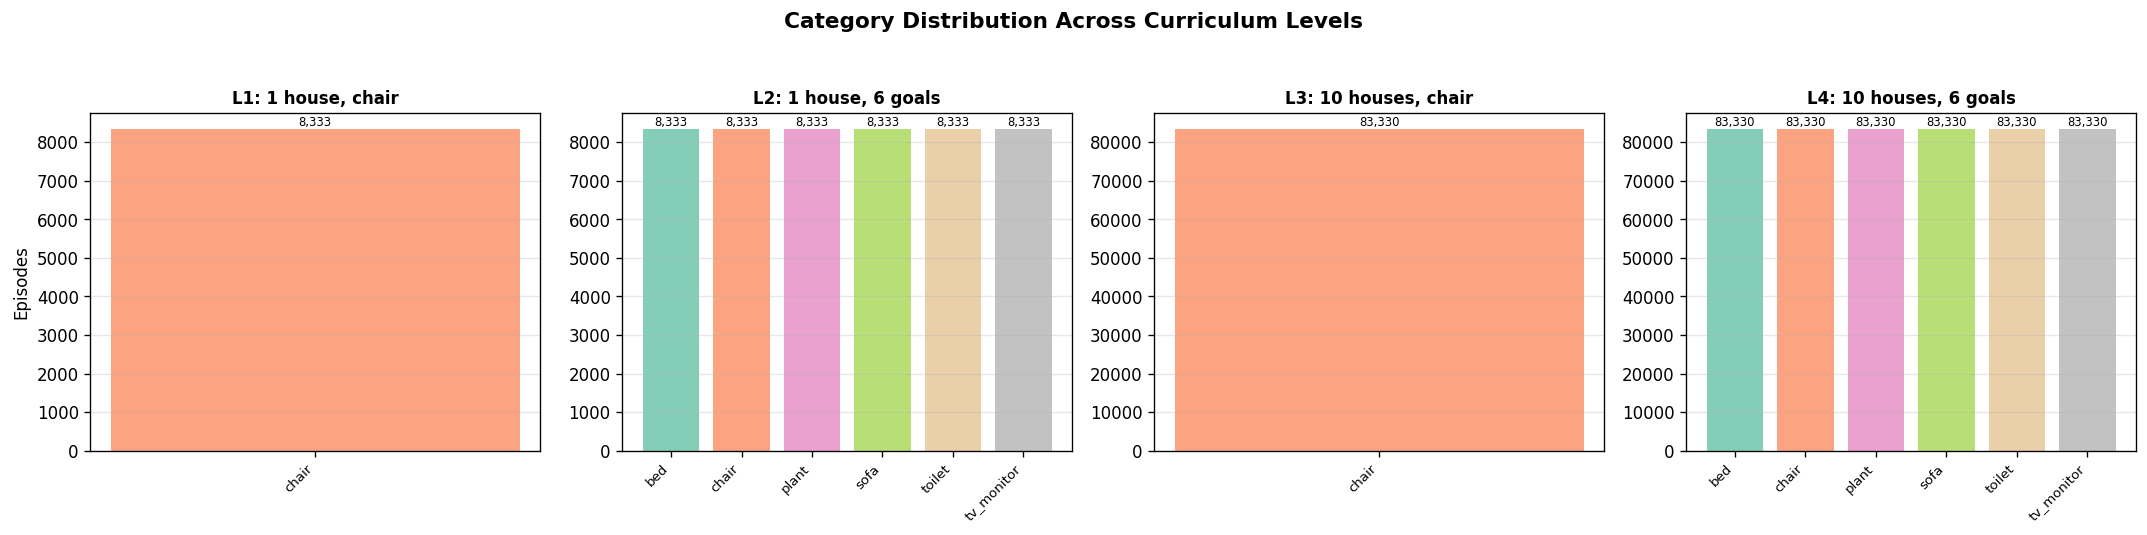

In [6]:
ALL_CATS = ["bed", "chair", "plant", "sofa", "toilet", "tv_monitor"]
CAT_COLORS = plt.cm.Set2(np.linspace(0, 1, len(ALL_CATS)))

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, name, label in zip(axes, LEVEL_NAMES, LEVEL_LABELS):
    all_keys = configs[name]["train_episode_keys"] + configs[name]["eval_episode_keys"]
    cat_counts = Counter(k[1] for k in all_keys)
    
    cats = [c for c in ALL_CATS if c in cat_counts]
    counts = [cat_counts[c] for c in cats]
    colors = [CAT_COLORS[ALL_CATS.index(c)] for c in cats]
    
    bars = ax.bar(range(len(cats)), counts, color=colors, alpha=0.8)
    ax.set_xticks(range(len(cats)))
    ax.set_xticklabels(cats, rotation=45, ha="right", fontsize=8)
    ax.set_title(label, fontweight="bold", fontsize=10)
    ax.set_ylabel("Episodes" if ax == axes[0] else "")
    ax.grid(True, alpha=0.3, axis="y")
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                f"{c:,}", ha="center", fontsize=7)

fig.suptitle("Category Distribution Across Curriculum Levels", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 5. Difficulty Progression Summary

Overlay all levels to show the progression in difficulty.

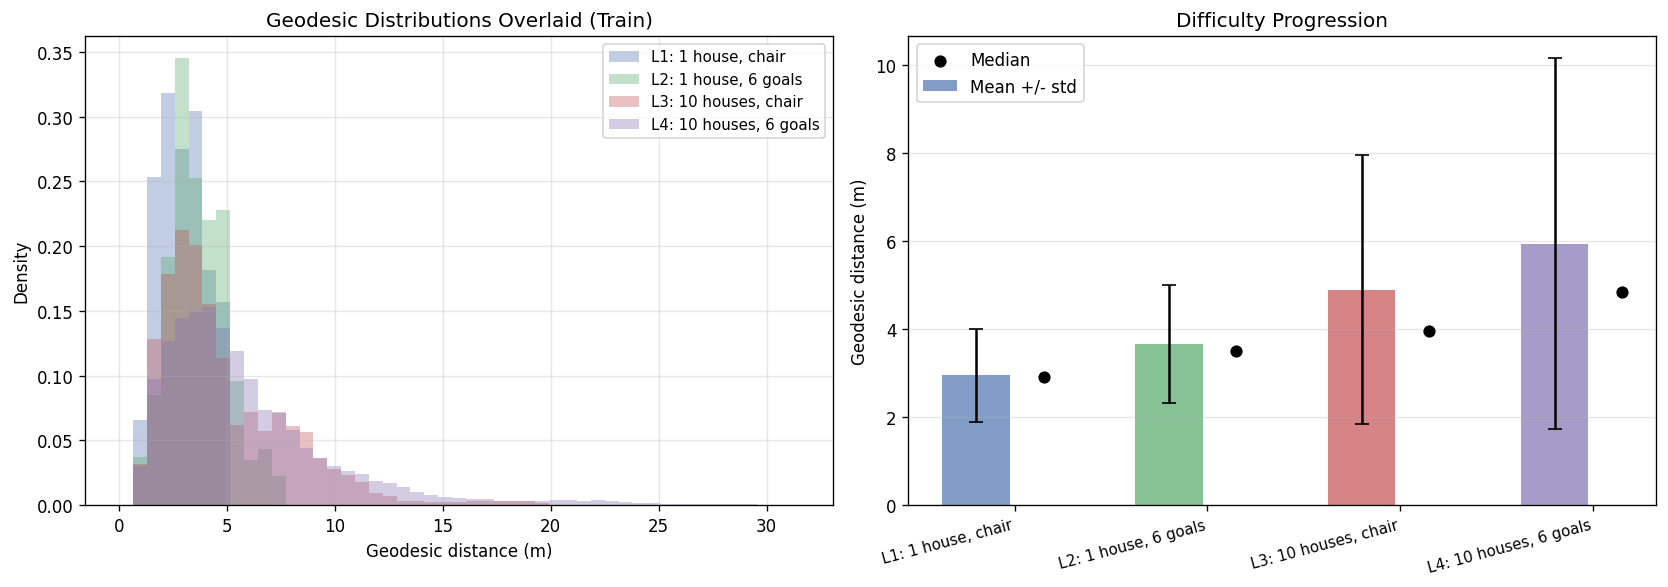

Level                        Train     Eval   Mean geo   Median      Std
------------------------------------------------------------------------
L1: 1 house, chair           7,499      834       2.95     2.91     1.06
L2: 1 house, 6 goals        44,998    5,000       3.67     3.51     1.33
L3: 10 houses, chair        74,997    8,333       4.90     3.97     3.06
L4: 10 houses, 6 goals     449,982   49,998       5.95     4.85     4.21


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlaid histograms (train only)
all_max = max(geodesics[n]["train"].max() for n in LEVEL_NAMES)
bins = np.linspace(0, all_max * 1.05, 50)

for name, label, color in zip(LEVEL_NAMES, LEVEL_LABELS, LEVEL_COLORS):
    d = geodesics[name]["train"]
    # Normalize to density for fair comparison
    axes[0].hist(d, bins=bins, alpha=0.35, color=color, label=label, density=True)

axes[0].set_xlabel("Geodesic distance (m)")
axes[0].set_ylabel("Density")
axes[0].set_title("Geodesic Distributions Overlaid (Train)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Summary stats table as bar chart
means = [geodesics[n]["train"].mean() for n in LEVEL_NAMES]
stds = [geodesics[n]["train"].std() for n in LEVEL_NAMES]
medians = [np.median(geodesics[n]["train"]) for n in LEVEL_NAMES]

x = np.arange(len(LEVEL_NAMES))
axes[1].bar(x - 0.2, means, 0.35, yerr=stds, label="Mean +/- std",
            color=LEVEL_COLORS, alpha=0.7, capsize=4)
axes[1].scatter(x + 0.15, medians, color="black", zorder=5, s=40, label="Median")
axes[1].set_xticks(x)
axes[1].set_xticklabels(LEVEL_LABELS, rotation=15, ha="right", fontsize=9)
axes[1].set_ylabel("Geodesic distance (m)")
axes[1].set_title("Difficulty Progression")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Print summary table
print(f"{'Level':<25s} {'Train':>8s} {'Eval':>8s} {'Mean geo':>10s} {'Median':>8s} {'Std':>8s}")
print("-" * 72)
for name, label in zip(LEVEL_NAMES, LEVEL_LABELS):
    s = configs[name]["stats"]
    d = geodesics[name]["train"]
    print(f"{label:<25s} {s['train_episodes']:>8,d} {s['eval_episodes']:>8,d} "
          f"{d.mean():>10.2f} {np.median(d):>8.2f} {d.std():>8.2f}")

## 6. Train/Eval Split Validation

Verify train and eval distributions match (no systematic bias in the split).

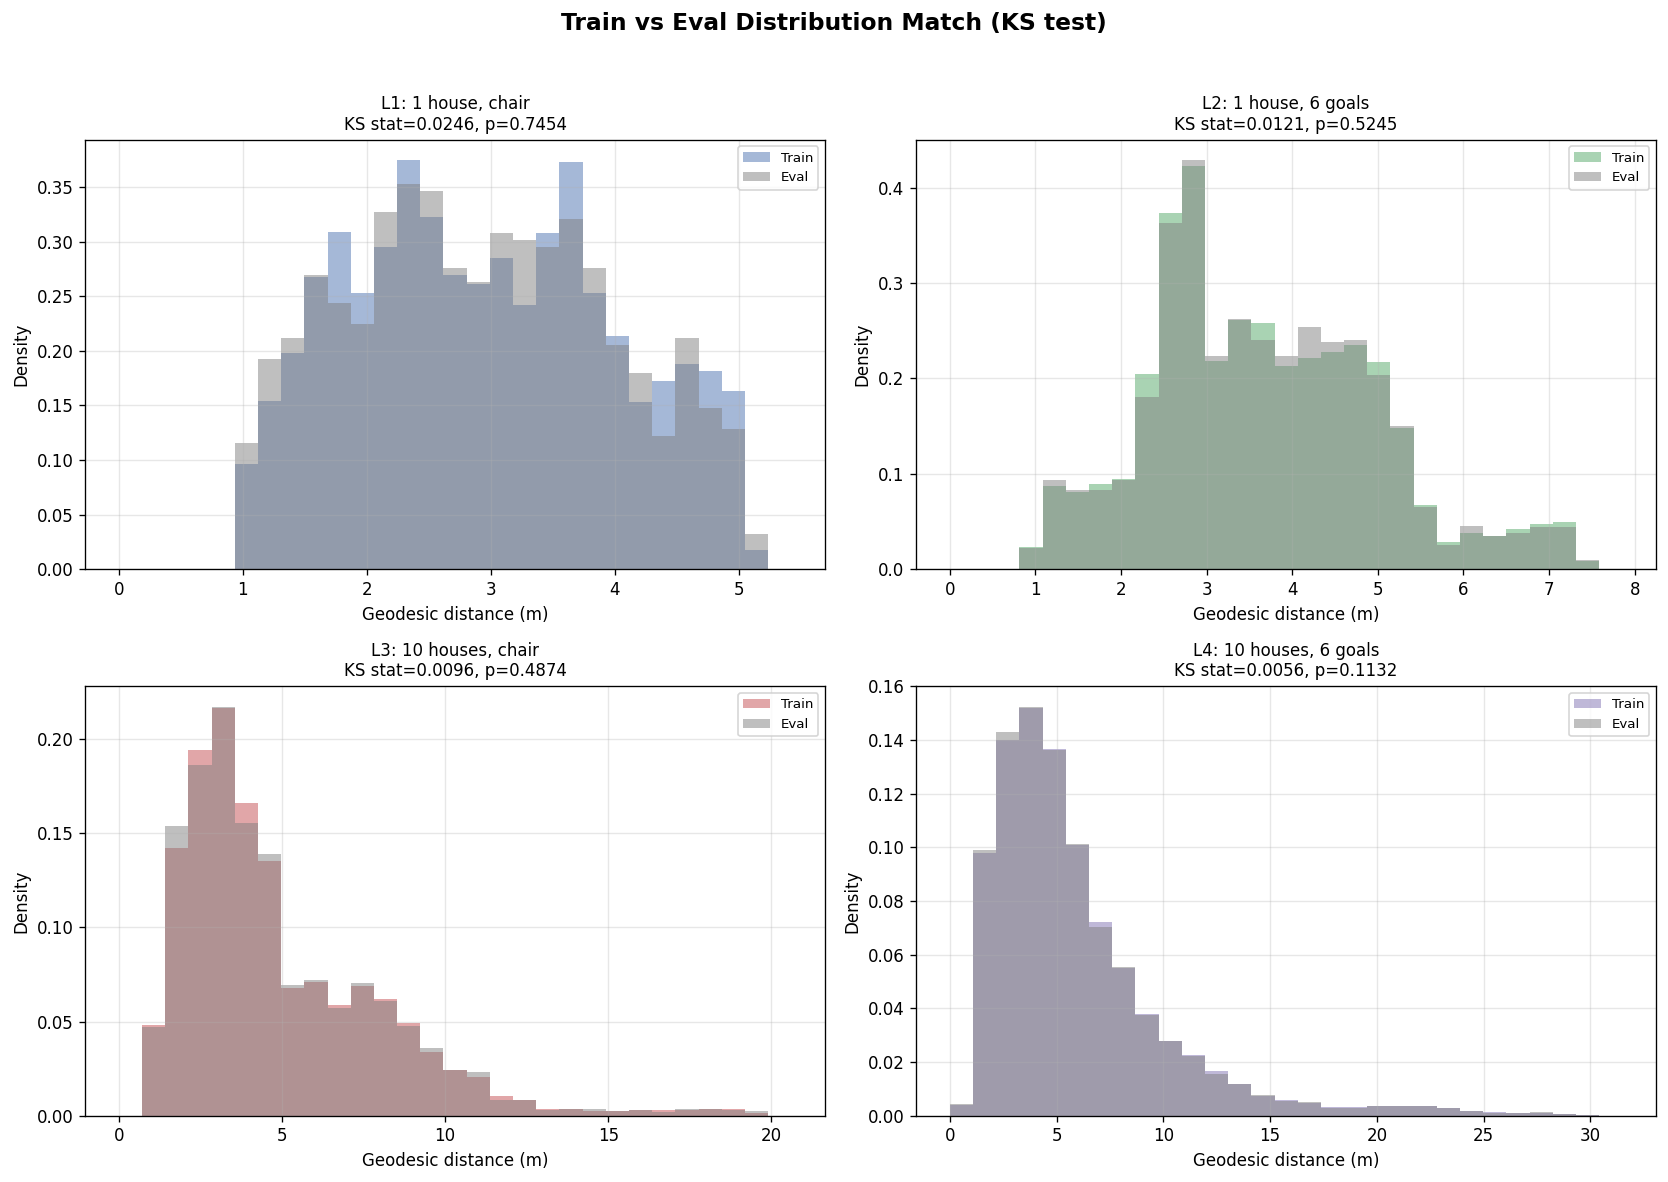

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, name, label, color in zip(axes.flat, LEVEL_NAMES, LEVEL_LABELS, LEVEL_COLORS):
    train_d = geodesics[name]["train"]
    eval_d = geodesics[name]["eval"]
    
    bins = np.linspace(0, max(train_d.max(), eval_d.max()) * 1.05, 30)
    ax.hist(train_d, bins=bins, alpha=0.5, density=True, label="Train", color=color)
    ax.hist(eval_d, bins=bins, alpha=0.5, density=True, label="Eval", color="gray")
    
    # KS test
    from scipy import stats
    ks_stat, ks_p = stats.ks_2samp(train_d, eval_d)
    ax.set_title(f"{label}\nKS stat={ks_stat:.4f}, p={ks_p:.4f}", fontsize=10)
    ax.set_xlabel("Geodesic distance (m)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Train vs Eval Distribution Match (KS test)", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()